In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

plt.rcParams["figure.figsize"] = (8, 5)


In [32]:

import seaborn as sns 
from sklearn.preprocessing import  LabelEncoder

In [33]:
data = pd.read_csv('SeoulBikeData.csv', encoding= 'unicode_escape')
data.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [34]:
print("Duplicate entry in data:",len(data[data.duplicated()])) 
data.describe().T


Duplicate entry in data: 0


,count,mean,std,min,25%,50%,75%,max
Rented Bike Count,8760.0,704.602055,644.997468,0.0,191.00,504.50,1065.25,3556.00
Hour,8760.0,11.500000,6.922582,0.0,5.75,11.50,17.25,23.00
Temperature(°C),8760.0,12.882922,11.944825,-17.8,3.50,13.70,22.50,39.40
Humidity(%),8760.0,58.226256,20.362413,0.0,42.00,57.00,74.00,98.00
Wind speed (m/s),8760.0,1.724909,1.036300,0.0,0.90,1.50,2.30,7.40
Visibility (10m),8760.0,1436.825799,608.298712,27.0,940.00,1698.00,2000.00,2000.00
Dew point temperature(°C),8760.0,4.073813,13.060369,-30.6,-4.70,5.10,14.80,27.20
Solar Radiation (MJ/m2),8760.0,0.569111,0.868746,0.0,0.00,0.01,0.93,3.52
Rainfall(mm),8760.0,0.148687,1.128193,0.0,0.00,0.00,0.00,35.00
Snowfall (cm),8760.0,0.075068,0.436746,0.0,0.00,0.00,0.00,8.80


In [35]:
print(data.shape)
# Grouping by functioning day and calculating the total Rented Bike Count
data.groupby('Functioning Day').sum()['Rented Bike Count']


(8760, 14)


Functioning Day
No           0
Yes    6172314
Name: Rented Bike Count, dtype: int64

In [36]:
#Since we only consider the functioning day here.
data2 = data[data['Functioning Day'] == 'Yes']
data2 = data2.drop(columns=['Functioning Day'])
data2.shape


(8465, 13)

In [37]:
protion_of_functioning_day = data2.shape[0] / data.shape[0]
print("Protion of Functioning Day in the whole data:", protion_of_functioning_day)


Protion of Functioning Day in the whole data: 0.966324200913242


In [38]:
#date time conversion
data2['Date'] = pd.to_datetime(data2['Date'],format='%d/%m/%Y') 
data2['Date']

0      2017-12-01
1      2017-12-01
2      2017-12-01
3      2017-12-01
4      2017-12-01
          ...    
8755   2018-11-30
8756   2018-11-30
8757   2018-11-30
8758   2018-11-30
8759   2018-11-30
Name: Date, Length: 8465, dtype: datetime64[ns]

In [39]:
data2['Day'] = data2['Date'].dt.day
data2['Month'] = data2['Date'].dt.month
data2['Year'] = data2['Date'].dt.year
data2['day_of_week'] = data2['Date'].dt.dayofweek
data2['is_weekend'] = data2['day_of_week'].isin([5,6]).astype(int)
data2.drop(columns='Date', inplace= True)
data2.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Day,Month,Year,day_of_week,is_weekend
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,4,0
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,4,0
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,4,0
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,4,0
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,4,0


In [40]:
data2 = data2.sort_values(["Year", "Month", "Day", "Hour"]).reset_index(drop=True)
data2.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Day,Month,Year,day_of_week,is_weekend
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,4,0
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,4,0
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,4,0
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,4,0
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,4,0


In [66]:
data2.describe().T
tsv = data2.head(5).to_csv(sep="\t", index=False)
print(tsv)

Rented Bike Count	Hour	Temperature(°C)	Humidity(%)	Wind speed (m/s)	Visibility (10m)	Dew point temperature(°C)	Solar Radiation (MJ/m2)	Rainfall(mm)	Snowfall (cm)	Seasons	Holiday	Day	Month	Year	day_of_week	is_weekend
254	0	-5.2	37	2.2	2000	-17.6	0.0	0.0	0.0	Winter	No Holiday	1	12	2017	4	0
204	1	-5.5	38	0.8	2000	-17.6	0.0	0.0	0.0	Winter	No Holiday	1	12	2017	4	0
173	2	-6.0	39	1.0	2000	-17.7	0.0	0.0	0.0	Winter	No Holiday	1	12	2017	4	0
107	3	-6.2	40	0.9	2000	-17.6	0.0	0.0	0.0	Winter	No Holiday	1	12	2017	4	0
78	4	-6.0	36	2.3	2000	-18.6	0.0	0.0	0.0	Winter	No Holiday	1	12	2017	4	0



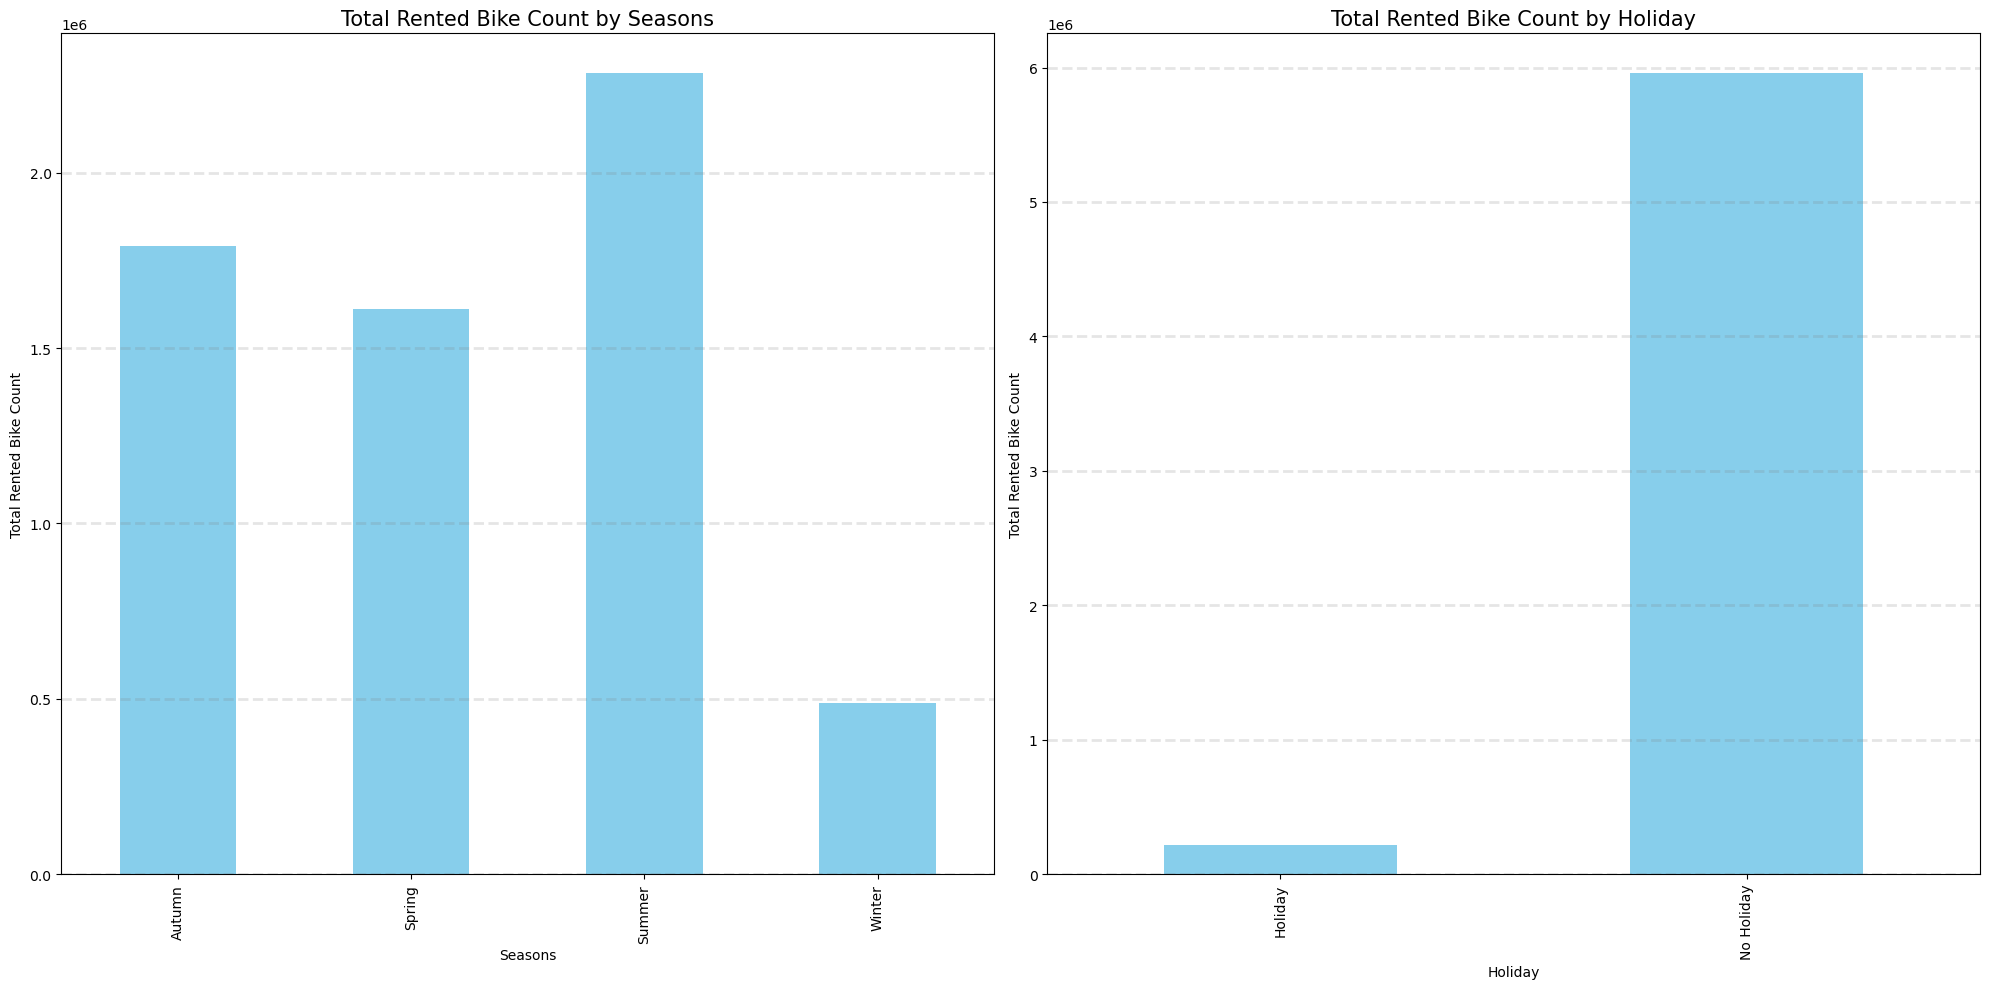

In [59]:
categorical_features = ['Seasons', 'Holiday']
fig = plt.figure(figsize = (20,10))
for index,column in enumerate(categorical_features) :
    plt.subplot(1,2,index+1)
    dataset=data2.copy()
    feature = data2[column]
    dataset.groupby(feature)['Rented Bike Count'].sum().plot(kind='bar',color='skyblue')
  
    ax = fig.gca()
    plt.title(f'Total Rented Bike Count by {column}', fontsize=15)
    plt.ylabel('Total Rented Bike Count')
    plt.tight_layout()
    plt.grid(color='grey', linestyle='--', linewidth=2, axis='y', alpha=0.2)

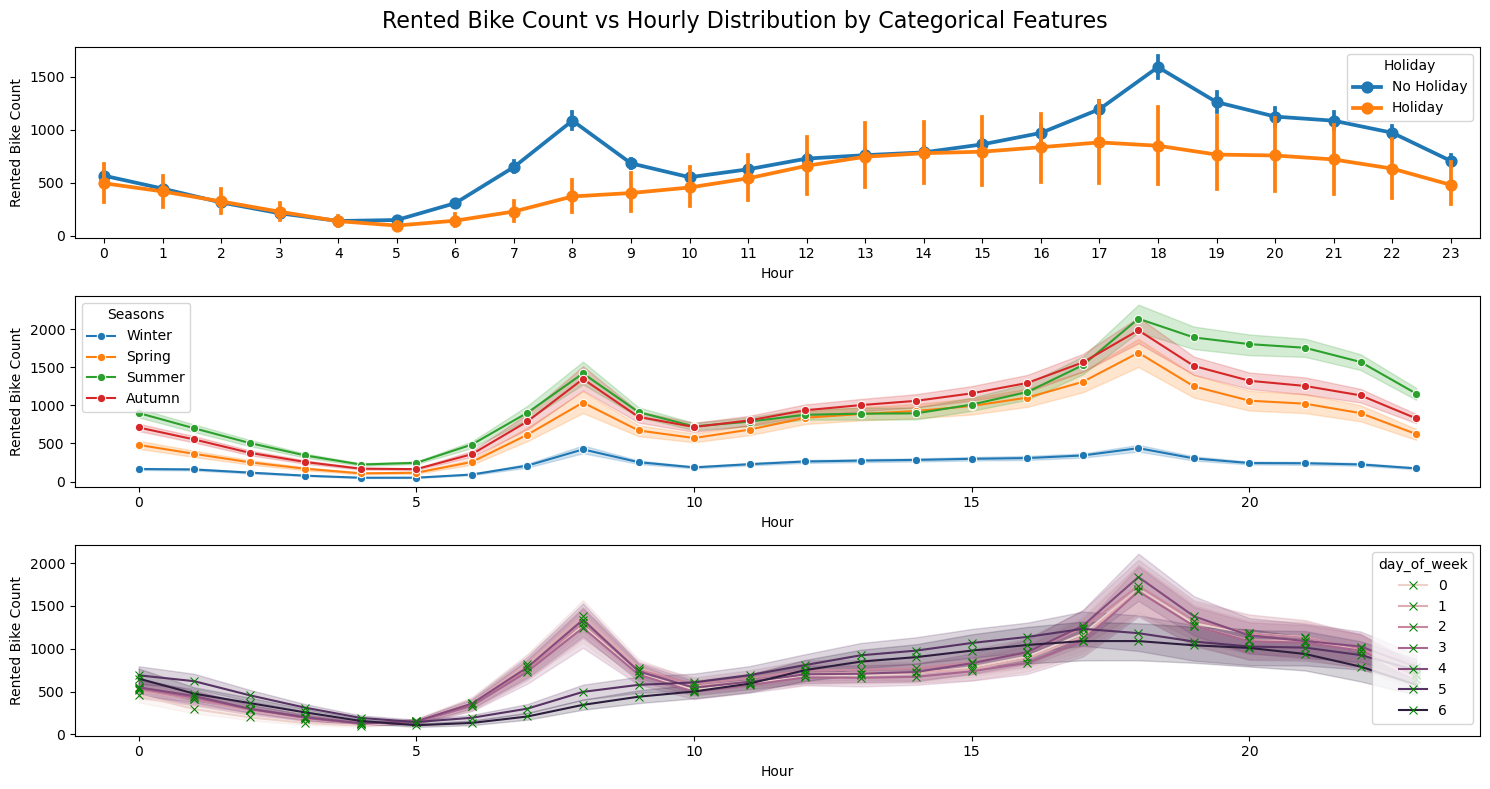

In [60]:
fig, axs = plt.subplots(nrows=3,ncols=1,figsize=(15,8), dpi=100)
sns.pointplot(data=dataset, x="Hour", y="Rented Bike Count", ax=axs[0], 
              hue="Holiday")
sns.lineplot(data=dataset, x="Hour", y="Rented Bike Count", ax=axs[1], 
              hue="Seasons", marker="o")
sns.lineplot(data=dataset, x="Hour", y="Rented Bike Count", ax=axs[2],
              hue="day_of_week", marker="x",markeredgecolor='green')
plt.suptitle('Rented Bike Count vs Hourly Distribution by Categorical Features', fontsize=16)
plt.tight_layout()

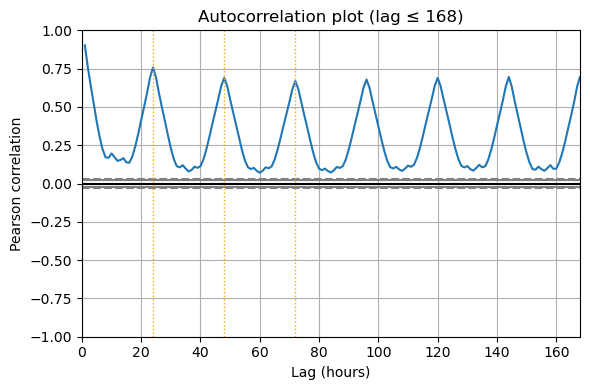

In [67]:
from pandas.plotting import autocorrelation_plot

# Autocorrelation plot using pandas built-in function
plt.figure(figsize=(6, 4))
autocorrelation_plot(data2['Rented Bike Count'])

plt.xlim(0, 168)
plt.title("Autocorrelation plot (lag ≤ 168)")
plt.xlabel("Lag (hours)")
plt.ylabel("Pearson correlation")
plt.axvline(24, color='orange', linestyle=':', linewidth=1)
plt.axvline(48, color='orange', linestyle=':', linewidth=1)
plt.axvline(72, color='orange', linestyle=':', linewidth=1)
plt.tight_layout()
plt.show()

In [41]:
#add lag features
lags = [ 24, 48, 72, 168]
data_lagged = data2.copy()

for lag in lags:
    col_name = f"Rented_lag_{lag}"
    data_lagged[col_name] = data_lagged["Rented Bike Count"].shift(lag)

data_lagged[["Rented Bike Count"] + [f"Rented_lag_{lag}" for lag in lags]].head(10)

,Rented Bike Count,Rented_lag_24,Rented_lag_48,Rented_lag_72,Rented_lag_168
0,254,NaN,NaN,NaN,NaN
1,204,NaN,NaN,NaN,NaN
2,173,NaN,NaN,NaN,NaN
3,107,NaN,NaN,NaN,NaN
4,78,NaN,NaN,NaN,NaN
5,100,NaN,NaN,NaN,NaN
6,181,NaN,NaN,NaN,NaN
7,460,NaN,NaN,NaN,NaN
8,930,NaN,NaN,NaN,NaN
9,490,NaN,NaN,NaN,NaN


In [42]:
max_lag = max(lags) 
data2_lagged = data_lagged.iloc[max_lag:].reset_index(drop=True)

data2_lagged.head()
print("orginal rows:", len(data_lagged), "   rows after lagging:", len(data2_lagged))



orginal rows: 8465    rows after lagging: 8297


In [ ]:
target_col = "Rented Bike Count"

categorical_features = ["Seasons", "Holiday", "day_of_week", "is_weekend"]

all_feature_cols = [c for c in data2_lagged.columns if c != target_col]

numeric_features = [c for c in all_feature_cols if c not in categorical_features]

print("Categorical features:", categorical_features)
print("Numeric features (with lag features):", numeric_features[:10], "...")

X_all = data2_lagged[all_feature_cols].copy()
y_all = data2_lagged[target_col].copy()

n_samples = len(data2_lagged)
test_size = int(n_samples * 0.2)
trainval_size = n_samples - test_size

X_trainval = X_all.iloc[:trainval_size].reset_index(drop=True)
y_trainval = y_all.iloc[:trainval_size].reset_index(drop=True)

X_test = X_all.iloc[trainval_size:].reset_index(drop=True)
y_test = y_all.iloc[trainval_size:].reset_index(drop=True)

print("Total samples:", n_samples)
print("train+val rows:", len(X_trainval))
print("test rows:", len(X_test))

Categorical features: ['Seasons', 'Holiday', 'day_of_week', 'is_weekend']
Numeric features (含 lag 特征): ['Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Day'] ...
总样本数: 8297
train+val 行数: 6638
test 行数: 1659


In [ ]:

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# One-Hot
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocess


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Hour', 'Temperature(°C)', 'Humidity(%)',
                                  'Wind speed (m/s)', 'Visibility (10m)',
                                  'Dew point temperature(°C)',
                                  'Solar Radiation (MJ/m2)', 'Rainfall(mm)',
                                  'Snowfall (cm)', 'Day', 'Month', 'Year',
                                  'Rented_lag_24', 'Rented_lag_48',
                                  'Rented_lag_72', 'Rented_lag_168']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Seasons', 'Holiday', 'day_of_week',
                                  'is_weekend'])])

<class 'numpy.ndarray'> (6638, 31)


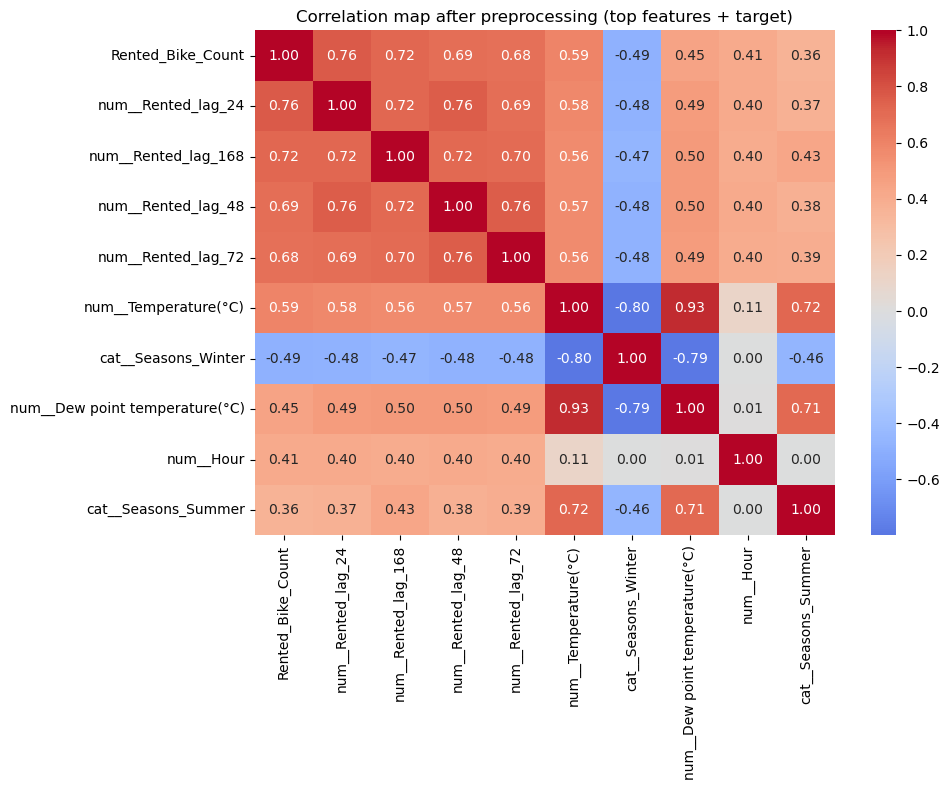

In [ ]:
# Cell: fit preprocess on trainval and transform

from scipy import sparse

# trainval fit ColumnTransformer
preprocess_fitted = preprocess.fit(X_trainval, y_trainval)

# trainval 做变换，得到预处理后的特征矩阵
X_trainval_proc = preprocess_fitted.transform(X_trainval)

print(type(X_trainval_proc), X_trainval_proc.shape)



# Cell: build DataFrame with processed feature names

import numpy as np
import pandas as pd

# ⭐ 直接从 ColumnTransformer 拿所有预处理后的特征名（避免手动拼出错）
proc_feature_names = preprocess_fitted.get_feature_names_out()

# 如果是稀疏矩阵，转成 dense
if sparse.issparse(X_trainval_proc):
    X_proc_dense = X_trainval_proc.toarray()
else:
    X_proc_dense = X_trainval_proc

# 做成 DataFrame（列数和特征名现在一定对齐）
X_proc_df = pd.DataFrame(X_proc_dense, columns=proc_feature_names)

X_proc_df.head()



# Cell: 把 target 也加到预处理后的 DataFrame 里

# 注意：y_trainval 和 X_trainval_proc 是一一对应的
y_proc = y_trainval.reset_index(drop=True)

X_proc_df_with_y = X_proc_df.copy()
X_proc_df_with_y["Rented_Bike_Count"] = y_proc

X_proc_df_with_y.head()



# Cell: 每个特征与 target 的 Pearson 相关系数

corr_full = X_proc_df_with_y.corr()

corr_with_target = corr_full["Rented_Bike_Count"].sort_values(ascending=False)
corr_with_target.head(20)



# Cell: 选出与 target 绝对相关性最高的前 20 个特征，画 heatmap

import matplotlib.pyplot as plt
import seaborn as sns

# 选出 |corr| 最大的前 20 个特征 + target 本身
top_k = 10
top_features = corr_with_target.abs().sort_values(ascending=False).head(top_k).index

# 这些特征之间的相关矩阵
corr_top = corr_full.loc[top_features, top_features]

plt.figure(figsize=(10, 8))
sns.heatmap(corr_top, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation map after preprocessing (top features + target)")
plt.tight_layout()
plt.show()


In [ ]:
# GridSearchCV + TimeSeriesSplit settings

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

# -RMSE
scoring = "neg_root_mean_squared_error"  


In [ ]:
# pipelines for base models

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor 

base_models = {}

# 1. Ridge regression
base_models["Ridge"] = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge())
])

# 2. Random Forest
base_models["RandomForest"] = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# 3. Gradient Boosting
base_models["GradientBoosting"] = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingRegressor(random_state=42))
])

# 4. XGBoost
base_models["XGBoost"] = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

list(base_models.keys())


['Ridge', 'RandomForest', 'GradientBoosting', 'XGBoost']

In [ ]:
# hyperparam param_grid

param_grids = {}

# 1. Ridge:  alpha（L2）
param_grids["Ridge"] = {
    "model__alpha": [0.1, 1.0, 10.0, 100.0]
}

# 2. Random Forest: 调树数、最大深度、叶子最小样本数
param_grids["RandomForest"] = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_leaf": [1, 3, 5]
}

# 3. Gradient Boosting: 调树数、学习率、最大深度
param_grids["GradientBoosting"] = {
    "model__n_estimators": [200, 400],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3]
}

# 4. XGBoost: 调树数、学习率、最大深度、子采样等
param_grids["XGBoost"] = {
    "model__n_estimators": [300, 500],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [1,3, 4,10],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}


In [49]:
# Cell 7: 使用 GridSearchCV + TimeSeriesSplit 调参

gs_results = []          # 存每个模型的最佳结果
best_estimators = {}     # 存每个模型调参后的最佳 pipeline

for name, pipe in base_models.items():
    print(f"\n==================== {name} ====================")
    param_grid = param_grids[name]
    
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=tscv,
        scoring=scoring,
        n_jobs=-1,
        refit=True,     # 调参完自动在全 trainval 上用最佳参数重训
        verbose=1
    )
    
    gs.fit(X_trainval, y_trainval)
    
    # 取出最佳结果（注意 scoring 是负 RMSE）
    best_rmse = -gs.best_score_
    best_params = gs.best_params_
    best_std = gs.cv_results_["std_test_score"][gs.best_index_]
    best_std = abs(best_std)  # 负号去掉
    
    print("Best params:", best_params)
    print(f"Best CV RMSE: {best_rmse:.3f} ± {best_std:.3f}")
    
    gs_results.append({
        "model": name,
        "best_rmse": best_rmse,
        "std_rmse": best_std,
        "best_params": best_params
    })
    
    # 保存调参好的最佳 estimator（包含 preprocess + model）
    best_estimators[name] = gs.best_estimator_



==================== Ridge ====================
Fitting 10 folds for each of 4 candidates, totalling 40 fits
Best params: {'model__alpha': 100.0}
Best CV RMSE: 328.575 ± 155.114

==================== RandomForest ====================
Fitting 10 folds for each of 18 candidates, totalling 180 fits
Best params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}
Best CV RMSE: 263.782 ± 105.612

==================== GradientBoosting ====================
Fitting 10 folds for each of 8 candidates, totalling 80 fits
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 400}
Best CV RMSE: 249.550 ± 105.112

==================== XGBoost ====================
Fitting 10 folds for each of 32 candidates, totalling 320 fits
Best params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 500, 'model__subsample': 1.0}
Best CV RMSE: 242.066 ± 98.700


,model,best_rmse,std_rmse
3,XGBoost,242.066239,98.699604
2,GradientBoosting,249.549890,105.112447
1,RandomForest,263.782157,105.612426
0,Ridge,328.575118,155.114463


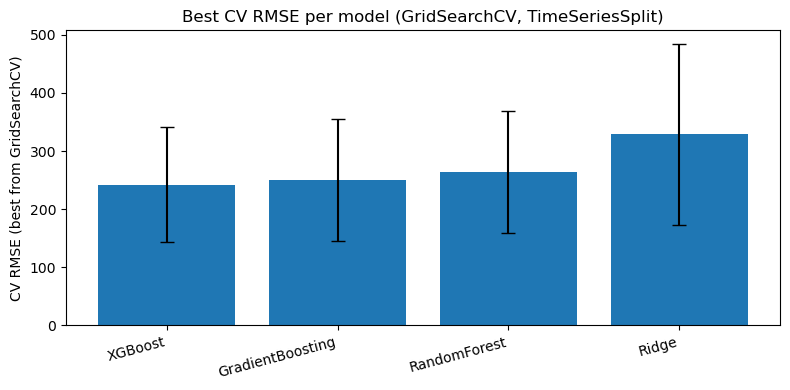

In [50]:
# Cell 8: 总结 GridSearchCV 结果

gs_df = pd.DataFrame(gs_results).sort_values("best_rmse")
display(gs_df[["model", "best_rmse", "std_rmse"]])

plt.figure(figsize=(8, 4))
plt.bar(gs_df["model"], gs_df["best_rmse"], yerr=gs_df["std_rmse"], capsize=5)
plt.ylabel("CV RMSE (best from GridSearchCV)")
plt.xticks(rotation=15, ha="right")
plt.title("Best CV RMSE per model (GridSearchCV, TimeSeriesSplit)")
plt.tight_layout()
plt.show()


In [51]:
# Cell 5: baselines (在 test 上计算 RMSE)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Baseline 1: mean of trainval
mean_baseline_value = y_trainval.mean()
y_test_pred_mean = np.full_like(y_test, fill_value=mean_baseline_value, dtype=float)
rmse_mean = rmse(y_test, y_test_pred_mean)

# Baseline 2: naive last-hour baseline (需要 Rented_lag_168 特征)
if "Rented_lag_168" in X_test.columns:
    y_test_pred_naive = X_test["Rented_lag_168"].values
    rmse_naive = rmse(y_test, y_test_pred_naive)
else:
    rmse_naive = None

print(f"Baseline 1 - Mean predictor RMSE on test: {rmse_mean:.3f}")
if rmse_naive is not None:
    print(f"Baseline 2 - Naive lag-168 RMSE on test: {rmse_naive:.3f}")
else:
    print("No 'Rented_lag_168' column found, naive baseline skipped.")

Baseline 1 - Mean predictor RMSE on test: 623.777
Baseline 2 - Naive lag-168 RMSE on test: 554.355


In [52]:
# Cell 9: 选出 CV 最好的模型，在 test 上评估

# 找 CV RMSE 最小的那一行
best_row = gs_df.iloc[0]
best_name = best_row["model"]
print("Best model by CV:", best_name)
print("Best params:", best_row["best_params"])
print(f"Best CV RMSE: {best_row['best_rmse']:.3f} ± {best_row['std_rmse']:.3f}")

best_pipe = best_estimators[best_name]

# 已经在 trainval 上 refit 过，但我们再保证一下
best_pipe.fit(X_trainval, y_trainval)

# 在 test 上预测
y_test_pred = best_pipe.predict(X_test)
test_rmse_best = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"\nTest RMSE ({best_name}): {test_rmse_best:.3f}")
print(f"Mean baseline RMSE: {rmse_mean:.3f}")
if rmse_naive is not None:
    print(f"Naive lag-168 baseline RMSE: {rmse_naive:.3f}")


Best model by CV: XGBoost
Best params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 500, 'model__subsample': 1.0}
Best CV RMSE: 242.066 ± 98.700

Test RMSE (XGBoost): 275.057
Mean baseline RMSE: 623.777
Naive lag-168 baseline RMSE: 554.355


In [ ]:
# best model & baselines  RMSE / MAE / R^2
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def print_regression_metrics(name, y_true, y_pred):
    rmse_val = rmse(y_true, y_pred)
    mae_val = mean_absolute_error(y_true, y_pred)
    r2_val = r2_score(y_true, y_pred)
    print(f"{name}:")
    print(f"  RMSE = {rmse_val:.3f}")
    print(f"  MAE  = {mae_val:.3f}")
    print(f"  R^2  = {r2_val:.3f}")
    print("-" * 40)

print_regression_metrics("Best model on TEST", y_test, y_test_pred)
print_regression_metrics("Mean baseline on TEST", y_test, y_test_pred_mean)

if "y_test_pred_naive" in globals():
    print_regression_metrics("Naive lag-168 baseline on TEST", y_test, y_test_pred_naive)


Best model on TEST:
  RMSE = 275.057
  MAE  = 176.647
  R^2  = 0.786
----------------------------------------
Mean baseline on TEST:
  RMSE = 623.777
  MAE  = 485.047
  R^2  = -0.101
----------------------------------------
Naive lag-168 baseline on TEST:
  RMSE = 554.355
  MAE  = 351.390
  R^2  = 0.130
----------------------------------------


In [ ]:
#GridSearchCV + TimeSeriesSplit (TRAIN only) for model selection (CV only)
#Defines VAR lag features (lags 1,2,3) for y + weather

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor



def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def metrics_dict(y_true, y_pred):
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

def time_split_60_20_20(df, target_col):
    n = len(df)
    n_train = int(n * 0.6)
    n_val   = int(n * 0.2)
    train = df.iloc[:n_train].reset_index(drop=True)
    val   = df.iloc[n_train:n_train+n_val].reset_index(drop=True)   # still used for refit boundary, but no metrics
    test  = df.iloc[n_train+n_val:].reset_index(drop=True)
    return train, val, test

def build_preprocess(numeric_features, categorical_features):
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    return ColumnTransformer([
        ("num", num_pipe, numeric_features),
        ("cat", cat_pipe, categorical_features)
    ])

# Define VAR lag feature dataset (lags 1,2,3) for y + weather

target_col = "Rented Bike Count"

temp_col  = "Temperature(°C)"
hum_col   = "Humidity(%)"
solar_col = "Solar Radiation (MJ/m2)"
rain_col  = "Rainfall(mm)"
wind_col  = "Wind speed (m/s)"

categorical_features = ["Seasons", "Holiday", "day_of_week", "is_weekend"]

lags_var = [1, 2, 3]
var_lag_cols = [target_col, temp_col, hum_col, solar_col, rain_col, wind_col]

data2_lagged_var = data2.copy()

missing_cols = [c for c in var_lag_cols if c not in data2_lagged_var.columns]
if missing_cols:
    raise ValueError(f"These columns are missing in data2: {missing_cols}")

for col in var_lag_cols:
    for L in lags_var:
        data2_lagged_var[f"{col}_lag_{L}"] = data2_lagged_var[col].shift(L)

data2_lagged_var = data2_lagged_var.iloc[max(lags_var):].reset_index(drop=True)
print("Built data2_lagged_var shape:", data2_lagged_var.shape)


# Models & param grids

models = {
    "Ridge": Ridge(),
    "RandomForest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1)
}

param_grids = {
    "Ridge": {"model__alpha": [0.1, 1.0, 10.0, 100.0]},
    "RandomForest": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 5, 10],
        "model__min_samples_leaf": [1, 3, 5]
    },
    "GradientBoosting": {
        "model__n_estimators": [200, 400],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3]
    },
    "XGBoost": {
        "model__n_estimators": [300, 500],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [3, 4],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    }
}

scoring = "neg_root_mean_squared_error"


def run_setting_cv_only(df, setting_name, target_col, categorical_features,
                        naive_baseline_col=None, n_splits_cv=5, verbose=1):
    """
    - chronological split: train/val/test = 60/20/20
    - GridSearchCV + TimeSeriesSplit on TRAIN only
    - refit best estimator on TRAIN+VAL, evaluate once on TEST
    - model ranking is based ONLY on CV_RMSE_mean (and CV_RMSE_std for stability)
    """
    train_df, val_df, test_df = time_split_60_20_20(df, target_col)

    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]

    X_val = val_df.drop(columns=[target_col])
    y_val = val_df[target_col]

    X_test = test_df.drop(columns=[target_col])
    y_test = test_df[target_col]

    feature_cols = list(X_train.columns)
    numeric_features = [c for c in feature_cols if c not in categorical_features]

    preprocess = build_preprocess(numeric_features, categorical_features)
    tscv = TimeSeriesSplit(n_splits=n_splits_cv)

    rows = []

    # Baselines 
    mean_test_pred = np.full_like(y_test.values, y_train.mean(), dtype=float)
    base_test = metrics_dict(y_test, mean_test_pred)
    rows.append({
        "Setting": setting_name,
        "Model": "MeanBaseline",
        "CV_RMSE_mean": np.nan, "CV_RMSE_std": np.nan,
        "TEST_RMSE": base_test["RMSE"], "TEST_MAE": base_test["MAE"], "TEST_R2": base_test["R2"],
        "BestParams": None
    })

    if naive_baseline_col is not None and naive_baseline_col in X_test.columns:
        naive_test = metrics_dict(y_test, X_test[naive_baseline_col].values)
        rows.append({
            "Setting": setting_name,
            "Model": f"Naive({naive_baseline_col})",
            "CV_RMSE_mean": np.nan, "CV_RMSE_std": np.nan,
            "TEST_RMSE": naive_test["RMSE"], "TEST_MAE": naive_test["MAE"], "TEST_R2": naive_test["R2"],
            "BestParams": None
        })

    gs_results = []
    best_estimators = {}

    for name, base_model in models.items():
        print(f"\n==================== {setting_name} | {name} ====================")

        pipe = Pipeline([
            ("preprocess", preprocess),
            ("model", base_model)
        ])

        gs = GridSearchCV(
            estimator=pipe,
            param_grid=param_grids[name],
            cv=tscv,
            scoring=scoring,
            n_jobs=-1,
            refit=True,     # refit on TRAIN only
            verbose=verbose
        )

        gs.fit(X_train, y_train)

        cv_rmse_mean = -gs.best_score_
        cv_rmse_std = abs(gs.cv_results_["std_test_score"][gs.best_index_])
        best_params = gs.best_params_

        print("Best params:", best_params)
        print(f"Best CV RMSE: {cv_rmse_mean:.3f} ± {cv_rmse_std:.3f}")

        gs_results.append({
            "Setting": setting_name,
            "Model": name,
            "CV_RMSE_mean": cv_rmse_mean,
            "CV_RMSE_std": cv_rmse_std,
            "BestParams": best_params
        })

        best_pipe = gs.best_estimator_
        best_estimators[name] = best_pipe

        #refit on TRAIN+VAL, then evaluate on TEST once
        X_trainval = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
        y_trainval = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

        best_pipe.fit(X_trainval, y_trainval)
        test_pred = best_pipe.predict(X_test)
        test_m = metrics_dict(y_test, test_pred)

        rows.append({
            "Setting": setting_name,
            "Model": name,
            "CV_RMSE_mean": cv_rmse_mean, "CV_RMSE_std": cv_rmse_std,
            "TEST_RMSE": test_m["RMSE"], "TEST_MAE": test_m["MAE"], "TEST_R2": test_m["R2"],
            "BestParams": best_params
        })

    results_df = pd.DataFrame(rows)
    gs_results_df = pd.DataFrame(gs_results)

    return results_df, gs_results_df, best_estimators



# Run settings (Long AR / VAR)
res_long, gs_long, best_long = run_setting_cv_only(
    df=data2_lagged,
    setting_name="Long AR",
    target_col=target_col,
    categorical_features=categorical_features,
    naive_baseline_col="Rented_lag_168",
    n_splits_cv=5,
    verbose=0
)

res_var, gs_var, best_var = run_setting_cv_only(
    df=data2_lagged_var,
    setting_name="VAR(1-3 on y+weather)",
    target_col=target_col,
    categorical_features=categorical_features,
    naive_baseline_col=f"{target_col}_lag_1",
    n_splits_cv=5,
    verbose=0
)

results_all = pd.concat([res_long, res_var], axis=0).reset_index(drop=True)

print("\n=== Full results (sorted by Setting then CV_RMSE_mean) ===")
display(results_all.sort_values(["Setting","CV_RMSE_mean"]))

print("\n=== Best model per setting (by CV_RMSE_mean, models only) ===")
model_names = list(models.keys())
best_per_setting = results_all[results_all["Model"].isin(model_names)] \
    .sort_values(["Setting","CV_RMSE_mean"]) \
    .groupby("Setting").head(1)

display(best_per_setting[["Setting","Model","CV_RMSE_mean","CV_RMSE_std","TEST_RMSE","TEST_R2"]])

print("\n=== Overall best (by CV_RMSE_mean across all settings/models) ===")
overall_best = results_all[results_all["Model"].isin(model_names)] \
    .sort_values("CV_RMSE_mean").head(1)

display(overall_best[["Setting","Model","CV_RMSE_mean","CV_RMSE_std","TEST_RMSE","TEST_R2"]])

# keep tuned estimators 
best_estimators_all = {
    "Long AR": best_long,
    "VAR(1-3 on y+weather)": best_var
}


Built data2_lagged_var shape: (8462, 35)

==================== Long AR | Ridge ====================
Best params: {'model__alpha': 100.0}
Best CV RMSE: 320.918 ± 169.406

==================== Long AR | RandomForest ====================
Best params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}
Best CV RMSE: 286.773 ± 127.496

==================== Long AR | GradientBoosting ====================
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}
Best CV RMSE: 272.811 ± 129.328

==================== Long AR | XGBoost ====================
Best params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 500, 'model__subsample': 0.8}
Best CV RMSE: 262.738 ± 120.606

==================== VAR(1-3 on y+weather) | Ridge ====================
Best params: {'model__alpha': 10.0}
Best CV RMSE: 221.814 ± 95.860

==================== VAR(1-3 on y+weather) | RandomFor

,Setting,Model,CV_RMSE_mean,CV_RMSE_std,TEST_RMSE,TEST_MAE,TEST_R2,BestParams
5,Long AR,XGBoost,262.737971,120.605579,274.070232,182.096054,0.787247,"{'model__colsample_bytree': 0.8, 'model__learn..."
4,Long AR,GradientBoosting,272.810525,129.327536,296.022942,195.160753,0.751800,"{'model__learning_rate': 0.1, 'model__max_dept..."
3,Long AR,RandomForest,286.773382,127.496459,307.976118,194.660602,0.731351,"{'model__max_depth': None, 'model__min_samples..."
2,Long AR,Ridge,320.918106,169.405630,342.023146,239.268249,0.668669,{'model__alpha': 100.0}
0,Long AR,MeanBaseline,NaN,NaN,658.040374,507.391759,-0.226469,None
1,Long AR,Naive(Rented_lag_168),NaN,NaN,554.188037,351.194578,0.130107,None
11,VAR(1-3 on y+weather),XGBoost,183.613596,75.160313,165.769601,110.559601,0.923497,"{'model__colsample_bytree': 1.0, 'model__learn..."
10,VAR(1-3 on y+weather),GradientBoosting,189.808980,77.595671,173.685658,112.684676,0.916016,"{'model__learning_rate': 0.05, 'model__max_dep..."
9,VAR(1-3 on y+weather),RandomForest,206.450311,83.580719,173.143348,104.866847,0.916539,"{'model__max_depth': None, 'model__min_samples..."
8,VAR(1-3 on y+weather),Ridge,221.814204,95.859985,274.457818,181.993820,0.790289,{'model__alpha': 10.0}



=== Best model per setting (by CV_RMSE_mean, models only) ===


,Setting,Model,CV_RMSE_mean,CV_RMSE_std,TEST_RMSE,TEST_R2,BestParams
5,Long AR,XGBoost,262.737971,120.605579,274.070232,0.787247,"{'model__colsample_bytree': 0.8, 'model__learn..."
11,VAR(1-3 on y+weather),XGBoost,183.613596,75.160313,165.769601,0.923497,"{'model__colsample_bytree': 1.0, 'model__learn..."



=== Overall best (by CV_RMSE_mean across all settings/models) ===


,Setting,Model,CV_RMSE_mean,CV_RMSE_std,TEST_RMSE,TEST_R2,BestParams
11,VAR(1-3 on y+weather),XGBoost,183.613596,75.160313,165.769601,0.923497,"{'model__colsample_bytree': 1.0, 'model__learn..."


Using pipeline: VAR(1-3 on y+weather) | XGBoost
VAR X_trainval shape: (6770, 34)
VAR X_test shape: (1692, 34)
X_test_proc shape: (1692, 45)
len(feature_names): 45

=== Global FI #1: Permutation (Top 20) ===


,feature,perm_mean,perm_std
12,Rented Bike Count_lag_1,581.248474,9.889849
0,Hour,94.079031,2.896019
23,Solar Radiation (MJ/m2)_lag_3,52.756361,2.311265
6,Solar Radiation (MJ/m2),52.287511,2.227075
13,Rented Bike Count_lag_2,52.047284,2.257087
14,Rented Bike Count_lag_3,31.028300,1.936772
1,Temperature(°C),15.054671,1.952943
43,is_weekend_0,9.278316,1.110285
7,Rainfall(mm),6.833134,1.031135
21,Solar Radiation (MJ/m2)_lag_1,1.670645,0.505765


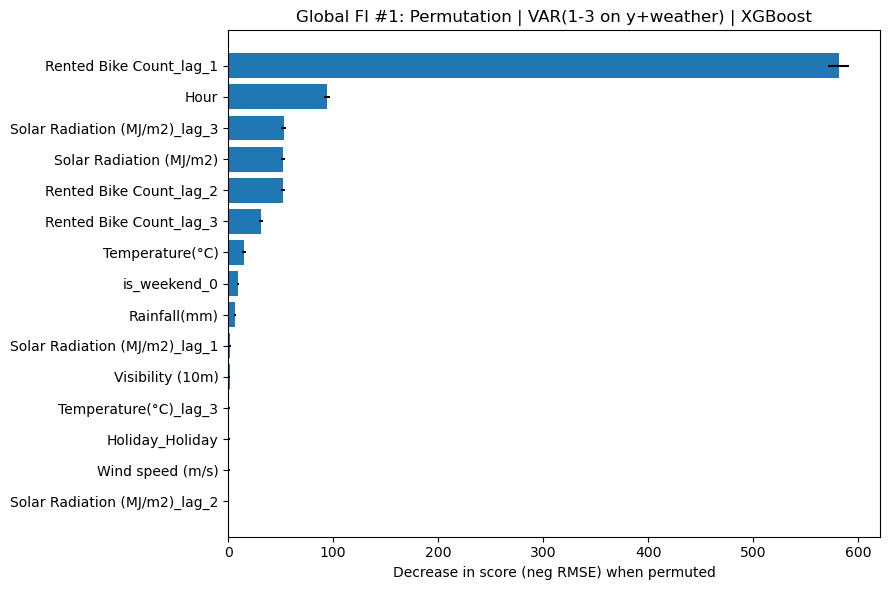


Using model-based FI: XGBoost gain

=== Global FI #2: Model-based (Top 20) ===


,feature,gain
12,Rented Bike Count_lag_1,2.629868e+07
23,Solar Radiation (MJ/m2)_lag_3,4.623904e+06
6,Solar Radiation (MJ/m2),3.127448e+06
0,Hour,1.428820e+06
1,Temperature(°C),1.359042e+06
22,Solar Radiation (MJ/m2)_lag_2,1.273689e+06
43,is_weekend_0,1.243262e+06
14,Rented Bike Count_lag_3,1.064689e+06
13,Rented Bike Count_lag_2,1.034170e+06
17,Temperature(°C)_lag_3,8.433254e+05


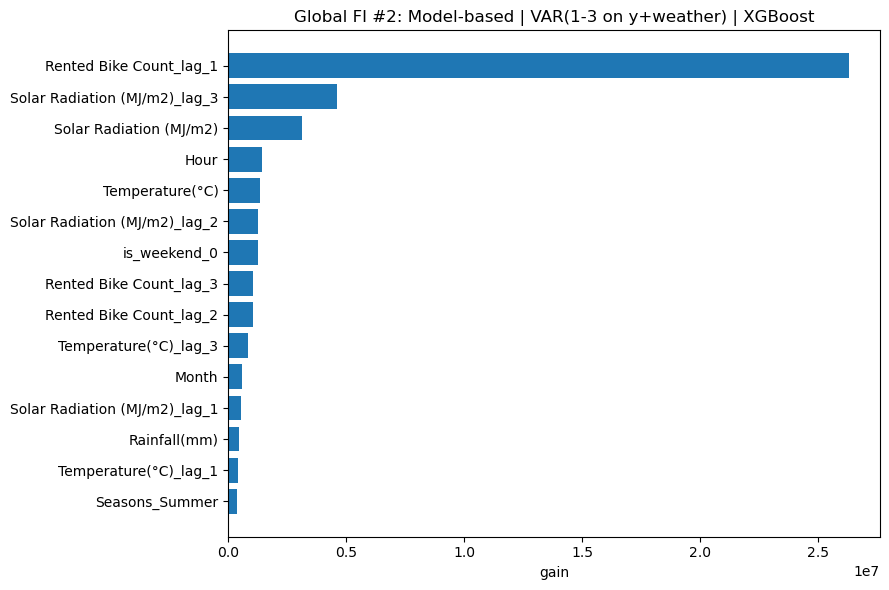


=== Global FI #3: SHAP mean(|value|) (Top 20) ===


,feature,shap_mean_abs
12,Rented Bike Count_lag_1,478.398018
0,Hour,84.352179
6,Solar Radiation (MJ/m2),83.976840
13,Rented Bike Count_lag_2,74.838683
1,Temperature(°C),59.503764
23,Solar Radiation (MJ/m2)_lag_3,50.610477
14,Rented Bike Count_lag_3,43.917093
10,Month,18.179037
7,Rainfall(mm),15.209526
43,is_weekend_0,13.396739


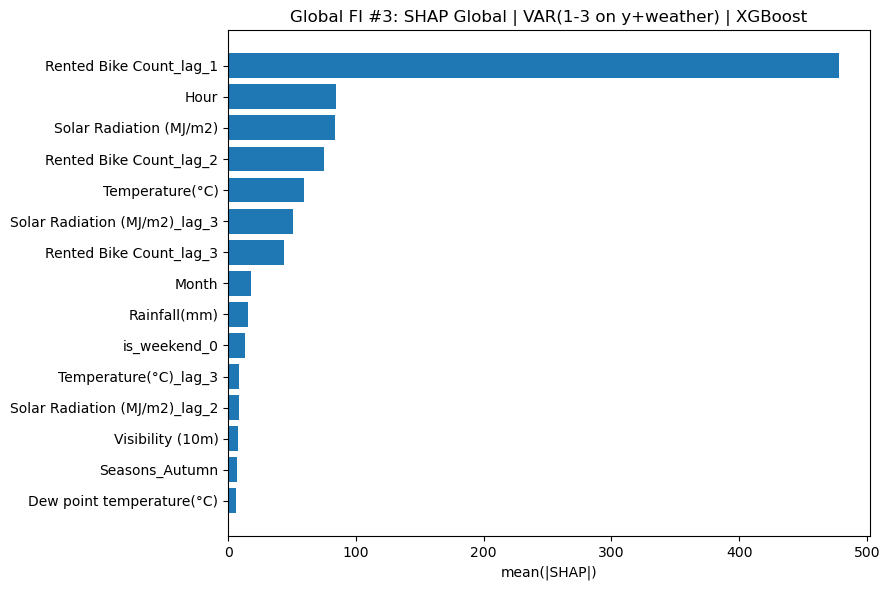

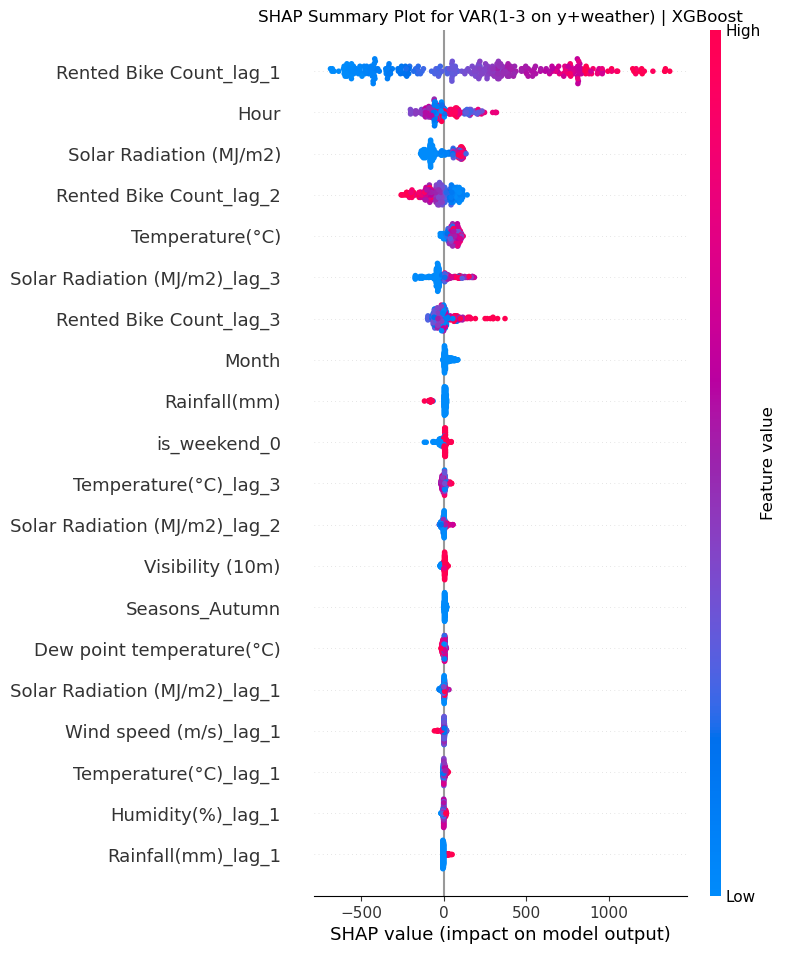


=== Local SHAP for test point i=0 ===


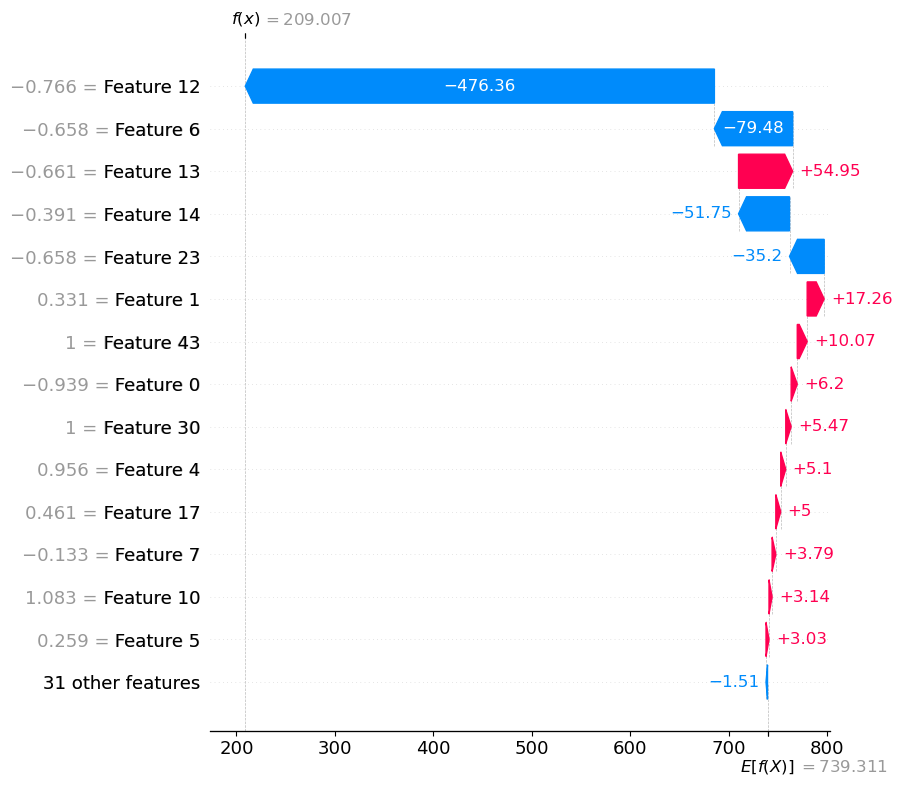

,feature,shap_value,abs_shap
12,Rented Bike Count_lag_1,-476.360124,476.360124
6,Solar Radiation (MJ/m2),-79.479723,79.479723
13,Rented Bike Count_lag_2,54.947155,54.947155
14,Rented Bike Count_lag_3,-51.754814,51.754814
23,Solar Radiation (MJ/m2)_lag_3,-35.202884,35.202884
1,Temperature(°C),17.261728,17.261728
43,is_weekend_0,10.073619,10.073619
0,Hour,6.195804,6.195804
30,Seasons_Autumn,5.466798,5.466798
4,Visibility (10m),5.101650,5.101650


In [62]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from scipy import sparse


SETTING_CHOICE = "VAR(1-3 on y+weather)"
MODEL_CHOICE = "XGBoost"   # "Ridge" / "RandomForest" / "GradientBoosting" / "XGBoost"
target_col = "Rented Bike Count"



pipe_to_explain = best_estimators_all[SETTING_CHOICE][MODEL_CHOICE]
print(f"Using pipeline: {SETTING_CHOICE} | {MODEL_CHOICE}")

# -----------------------
# 2) build correct trainval/test for VAR setting (80/20 time split)
#    (IMPORTANT: must match the feature columns used when training this setting)
# -----------------------
df_var = data2_lagged_var.copy()

n = len(df_var)
test_size = int(n * 0.2)
trainval_size = n - test_size

trainval_var = df_var.iloc[:trainval_size].reset_index(drop=True)
test_var     = df_var.iloc[trainval_size:].reset_index(drop=True)

X_trainval_var = trainval_var.drop(columns=[target_col])
y_trainval_var = trainval_var[target_col]

X_test_var = test_var.drop(columns=[target_col])
y_test_var = test_var[target_col]

print("VAR X_trainval shape:", X_trainval_var.shape)
print("VAR X_test shape:", X_test_var.shape)

# -----------------------
# 3) helpers
# -----------------------
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred, squared=False)

def get_feature_names_from_preprocess(preprocess_fitted):
    """
    Extract one-hot-level feature names from fitted ColumnTransformer.
    Assumes branches like:
      ("num", Pipeline([...]), numeric_cols)
      ("cat", Pipeline([... ("onehot", OneHotEncoder(...)) ...]), categorical_cols)
    """
    feature_names = []
    for name, trans, cols in preprocess_fitted.transformers_:
        if name == "remainder" and trans == "drop":
            continue

        if hasattr(trans, "named_steps"):
            if "onehot" in trans.named_steps:
                ohe = trans.named_steps["onehot"]
                feature_names.extend(list(ohe.get_feature_names_out(cols)))
            else:
                feature_names.extend(list(cols))
        else:
            feature_names.extend(list(cols))
    return np.array(feature_names)

# -----------------------
# 4) split pipeline into preprocess + model, transform data
# -----------------------
preprocess_fitted = pipe_to_explain.named_steps["preprocess"]
model = pipe_to_explain.named_steps["model"]

X_test_proc = preprocess_fitted.transform(X_test_var)
X_train_proc = preprocess_fitted.transform(X_trainval_var)

if sparse.issparse(X_test_proc):
    X_test_proc = X_test_proc.toarray()
if sparse.issparse(X_train_proc):
    X_train_proc = X_train_proc.toarray()

feature_names = get_feature_names_from_preprocess(preprocess_fitted)
print("X_test_proc shape:", X_test_proc.shape)
print("len(feature_names):", len(feature_names))
assert X_test_proc.shape[1] == len(feature_names), "特征名数量 != transform 后列数"

# -----------------------
# 5) Global FI #1: Permutation importance (model-agnostic)
# -----------------------
perm = permutation_importance(
    model,
    X_test_proc, y_test_var,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error"
)

perm_df = pd.DataFrame({
    "feature": feature_names,
    "perm_mean": perm.importances_mean,
    "perm_std": perm.importances_std
}).sort_values("perm_mean", ascending=False)

print("\n=== Global FI #1: Permutation (Top 20) ===")
display(perm_df.head(20))

top = perm_df.head(15)
plt.figure(figsize=(9, 6))
plt.barh(top["feature"], top["perm_mean"], xerr=top["perm_std"])
plt.gca().invert_yaxis()
plt.xlabel("Decrease in score (neg RMSE) when permuted")
plt.title(f"Global FI #1: Permutation | {SETTING_CHOICE} | {MODEL_CHOICE}")
plt.tight_layout()
plt.show()

# -----------------------
# 6) Global FI #2: Model-based importance
#    - XGBoost gain (preferred)
#    - else feature_importances_
#    - else abs(coef_)
# -----------------------
model_fi_df = None

# XGBoost gain
try:
    booster = model.get_booster()
    gain_dict = booster.get_score(importance_type="gain")  # keys: f0, f1, ...
    gain = np.zeros(len(feature_names), dtype=float)
    for k, v in gain_dict.items():
        idx = int(k.replace("f", ""))
        if 0 <= idx < len(gain):
            gain[idx] = v
    model_fi_df = pd.DataFrame({"feature": feature_names, "gain": gain}).sort_values("gain", ascending=False)
    ycol = "gain"
    print("\nUsing model-based FI: XGBoost gain")
except Exception:
    if hasattr(model, "feature_importances_"):
        fi = model.feature_importances_
        model_fi_df = pd.DataFrame({"feature": feature_names, "feature_importance": fi}).sort_values("feature_importance", ascending=False)
        ycol = "feature_importance"
        print("\nUsing model-based FI: feature_importances_")
    elif hasattr(model, "coef_"):
        coef = np.ravel(model.coef_)
        model_fi_df = pd.DataFrame({"feature": feature_names, "abs_coef": np.abs(coef), "coef": coef}).sort_values("abs_coef", ascending=False)
        ycol = "abs_coef"
        print("\nUsing model-based FI: abs(coef_)")
    else:
        print("\nModel-based FI not available for this estimator.")
        ycol = None

if model_fi_df is not None:
    print("\n=== Global FI #2: Model-based (Top 20) ===")
    display(model_fi_df.head(20))

    top2 = model_fi_df.head(15)
    plt.figure(figsize=(9, 6))
    plt.barh(top2["feature"], top2[ycol])
    plt.gca().invert_yaxis()
    plt.xlabel(ycol)
    plt.title(f"Global FI #2: Model-based | {SETTING_CHOICE} | {MODEL_CHOICE}")
    plt.tight_layout()
    plt.show()

# -----------------------
# 7) Global FI #3 + Local: SHAP
# -----------------------
try:
    import shap
except ImportError:
    !pip -q install shap
    import shap

rng = np.random.RandomState(42)
bg_n = min(200, X_train_proc.shape[0])
bg_idx = rng.choice(X_train_proc.shape[0], size=bg_n, replace=False)
X_bg = X_train_proc[bg_idx]

explain_n = min(300, X_test_proc.shape[0])
X_explain = X_test_proc[:explain_n]

explainer = shap.Explainer(model, X_bg)
shap_values = explainer(X_explain)

# Global SHAP: mean(|SHAP|)
shap_global = np.mean(np.abs(shap_values.values), axis=0)
shap_df = pd.DataFrame({
    "feature": feature_names,
    "shap_mean_abs": shap_global
}).sort_values("shap_mean_abs", ascending=False)

print("\n=== Global FI #3: SHAP mean(|value|) (Top 20) ===")
display(shap_df.head(20))

top3 = shap_df.head(15)
plt.figure(figsize=(9, 6))
plt.barh(top3["feature"], top3["shap_mean_abs"])
plt.gca().invert_yaxis()
plt.xlabel("mean(|SHAP|)")
plt.title(f"Global FI #3: SHAP Global | {SETTING_CHOICE} | {MODEL_CHOICE}")
plt.tight_layout()
plt.show()

# SHAP summary plot (global)
shap.summary_plot(shap_values.values, X_explain, feature_names=feature_names, show=False)
plt.title(f"SHAP Summary Plot for {SETTING_CHOICE} | {MODEL_CHOICE}")
plt.show()

# Local SHAP for a single point
i = 0
print(f"\n=== Local SHAP for test point i={i} ===")
shap.plots.waterfall(shap_values[i], max_display=15)

local_contrib = pd.DataFrame({
    "feature": feature_names,
    "shap_value": shap_values.values[i],
    "abs_shap": np.abs(shap_values.values[i]),
}).sort_values("abs_shap", ascending=False)

display(local_contrib.head(15))


Using pipeline: Long AR | XGBoost
Long AR X_trainval shape: (6638, 20)
Long AR X_test shape: (1659, 20)
X_test_proc shape: (1659, 31)
len(feature_names): 31

=== Global FI #1: Permutation (Top 20) ===


,feature,perm_mean,perm_std
2,Humidity(%),87.194205,3.589377
15,Rented_lag_168,83.080582,4.343933
0,Hour,82.594446,3.099380
12,Rented_lag_24,68.929413,3.913711
1,Temperature(°C),55.968063,2.077526
6,Solar Radiation (MJ/m2),43.133569,2.662373
14,Rented_lag_72,40.928409,1.226011
7,Rainfall(mm),35.193924,4.610173
29,is_weekend_0,14.114630,1.746612
20,Holiday_Holiday,4.772983,1.140491


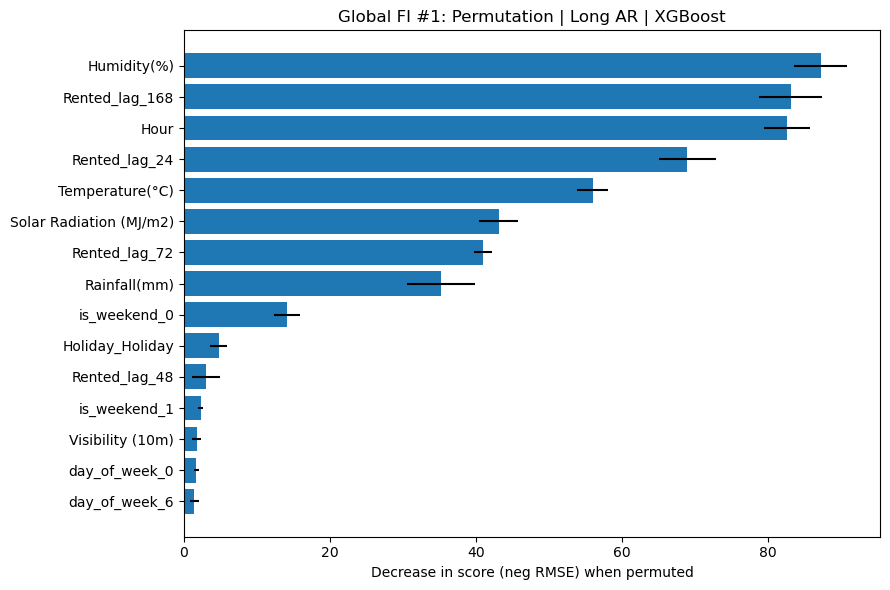


Using model-based FI: XGBoost gain

=== Global FI #2: Model-based (Top 20) ===


,feature,gain
12,Rented_lag_24,1.297957e+07
7,Rainfall(mm),7.220300e+06
15,Rented_lag_168,5.919684e+06
2,Humidity(%),4.654489e+06
14,Rented_lag_72,3.753780e+06
1,Temperature(°C),1.881644e+06
29,is_weekend_0,1.850077e+06
0,Hour,1.257890e+06
30,is_weekend_1,8.186336e+05
13,Rented_lag_48,7.981712e+05


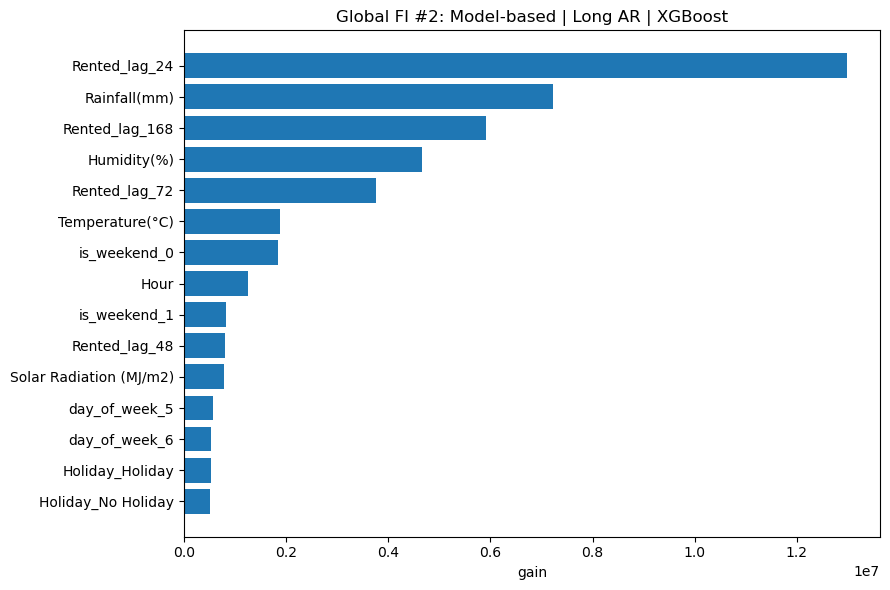


=== Global FI #3: SHAP mean(|value|) (Top 20) ===


,feature,shap_mean_abs
1,Temperature(°C),208.182319
15,Rented_lag_168,161.097792
0,Hour,129.588380
12,Rented_lag_24,108.797899
14,Rented_lag_72,87.406925
6,Solar Radiation (MJ/m2),84.005222
2,Humidity(%),76.786248
7,Rainfall(mm),42.280041
13,Rented_lag_48,27.660534
29,is_weekend_0,23.951835


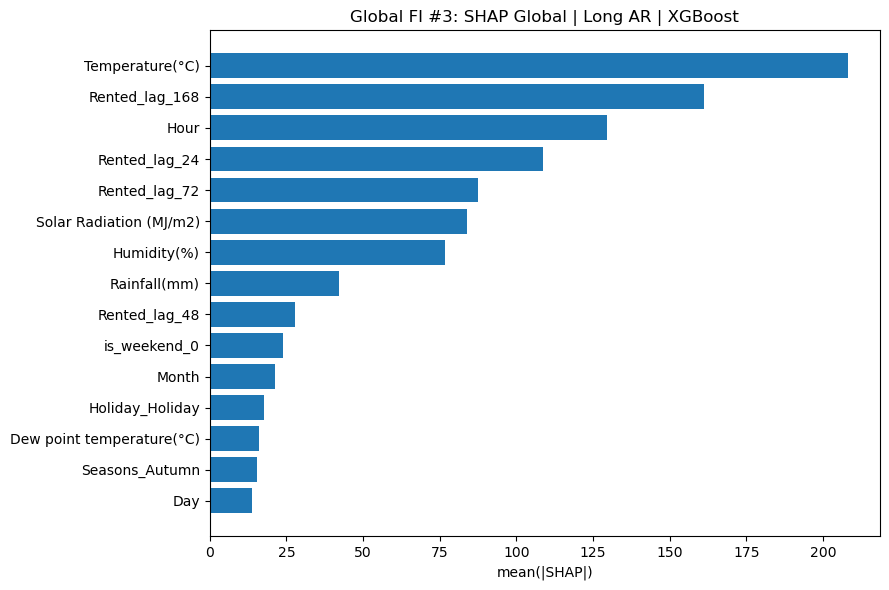

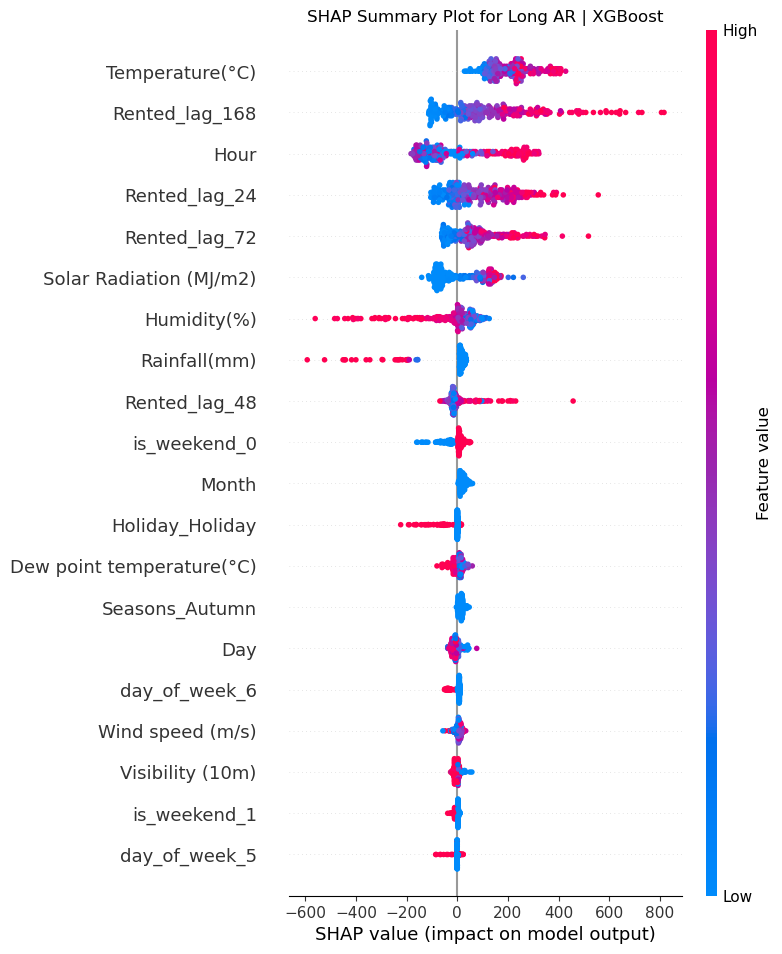


=== Local SHAP for test point i=0 ===


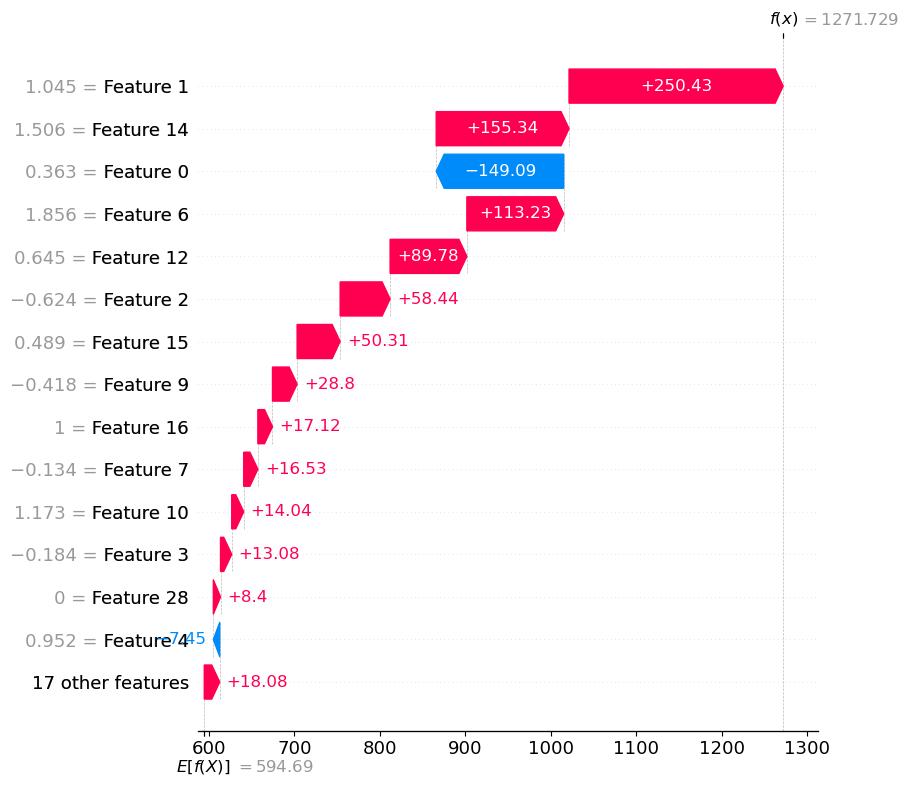

,feature,shap_value,abs_shap
1,Temperature(°C),250.426123,250.426123
14,Rented_lag_72,155.341455,155.341455
0,Hour,-149.093806,149.093806
6,Solar Radiation (MJ/m2),113.230402,113.230402
12,Rented_lag_24,89.783279,89.783279
2,Humidity(%),58.437803,58.437803
15,Rented_lag_168,50.314697,50.314697
9,Day,28.795434,28.795434
16,Seasons_Autumn,17.121090,17.121090
7,Rainfall(mm),16.527618,16.527618


In [ ]:
# =========================
# ONE CELL: Explain Long AR setting
# - builds correct X_trainval_long/X_test_long from data2_lagged
# - picks tuned pipeline from best_estimators_all
# - computes 3 global feature importances + SHAP local
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from scipy import sparse

# -----------------------
# 0) config: choose which Long AR model to explain
# -----------------------
SETTING_CHOICE = "Long AR"
MODEL_CHOICE = "XGBoost"   # "Ridge" / "RandomForest" / "GradientBoosting" / "XGBoost"
target_col = "Rented Bike Count"

# -----------------------
# 1) sanity checks
# -----------------------
if "data2_lagged" not in globals():
    raise NameError("can't find data2_lagged（Long AR dataset）。")

if "best_estimators_all" not in globals():
    raise NameError("can't find best_estimators_all. Please run the GridSearchCV code to generate best_estimators_all first.")

if SETTING_CHOICE not in best_estimators_all:
    raise KeyError(f"best_estimators_all does not contain this setting: {SETTING_CHOICE}. Available: {list(best_estimators_all.keys())}")

if MODEL_CHOICE not in best_estimators_all[SETTING_CHOICE]:
    raise KeyError(f"{SETTING_CHOICE} don't have {MODEL_CHOICE}. available: {list(best_estimators_all[SETTING_CHOICE].keys())}")

pipe_to_explain = best_estimators_all[SETTING_CHOICE][MODEL_CHOICE]
print(f"Using pipeline: {SETTING_CHOICE} | {MODEL_CHOICE}")

# -----------------------
# 2) build correct trainval/test for Long AR setting (80/20 time split)
# -----------------------
df_long = data2_lagged.copy()

n = len(df_long)
test_size = int(n * 0.2)
trainval_size = n - test_size

trainval_long = df_long.iloc[:trainval_size].reset_index(drop=True)
test_long     = df_long.iloc[trainval_size:].reset_index(drop=True)

X_trainval_long = trainval_long.drop(columns=[target_col])
y_trainval_long = trainval_long[target_col]

X_test_long = test_long.drop(columns=[target_col])
y_test_long = test_long[target_col]

print("Long AR X_trainval shape:", X_trainval_long.shape)
print("Long AR X_test shape:", X_test_long.shape)

# -----------------------
# 3) helpers
# -----------------------
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred, squared=False)

def get_feature_names_from_preprocess(preprocess_fitted):
    feature_names = []
    for name, trans, cols in preprocess_fitted.transformers_:
        if name == "remainder" and trans == "drop":
            continue

        if hasattr(trans, "named_steps"):
            if "onehot" in trans.named_steps:
                ohe = trans.named_steps["onehot"]
                feature_names.extend(list(ohe.get_feature_names_out(cols)))
            else:
                feature_names.extend(list(cols))
        else:
            feature_names.extend(list(cols))
    return np.array(feature_names)

# -----------------------
# 4) split pipeline into preprocess + model, transform data
# -----------------------
preprocess_fitted = pipe_to_explain.named_steps["preprocess"]
model = pipe_to_explain.named_steps["model"]

X_test_proc = preprocess_fitted.transform(X_test_long)
X_train_proc = preprocess_fitted.transform(X_trainval_long)

if sparse.issparse(X_test_proc):
    X_test_proc = X_test_proc.toarray()
if sparse.issparse(X_train_proc):
    X_train_proc = X_train_proc.toarray()

feature_names = get_feature_names_from_preprocess(preprocess_fitted)
print("X_test_proc shape:", X_test_proc.shape)
print("len(feature_names):", len(feature_names))
assert X_test_proc.shape[1] == len(feature_names), "feature number != transform column count"

# -----------------------
# 5) Global FI #1: Permutation importance
# -----------------------
perm = permutation_importance(
    model,
    X_test_proc, y_test_long,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error"
)

perm_df = pd.DataFrame({
    "feature": feature_names,
    "perm_mean": perm.importances_mean,
    "perm_std": perm.importances_std
}).sort_values("perm_mean", ascending=False)

print("\n=== Global FI #1: Permutation (Top 20) ===")
display(perm_df.head(20))

top = perm_df.head(15)
plt.figure(figsize=(9, 6))
plt.barh(top["feature"], top["perm_mean"], xerr=top["perm_std"])
plt.gca().invert_yaxis()
plt.xlabel("Decrease in score (neg RMSE) when permuted")
plt.title(f"Global FI #1: Permutation | {SETTING_CHOICE} | {MODEL_CHOICE}")
plt.tight_layout()
plt.show()

# -----------------------
# 6) Global FI #2: Model-based importance
# -----------------------
model_fi_df = None

try:
    booster = model.get_booster()
    gain_dict = booster.get_score(importance_type="gain")
    gain = np.zeros(len(feature_names), dtype=float)
    for k, v in gain_dict.items():
        idx = int(k.replace("f", ""))
        if 0 <= idx < len(gain):
            gain[idx] = v
    model_fi_df = pd.DataFrame({"feature": feature_names, "gain": gain}).sort_values("gain", ascending=False)
    ycol = "gain"
    print("\nUsing model-based FI: XGBoost gain")
except Exception:
    if hasattr(model, "feature_importances_"):
        fi = model.feature_importances_
        model_fi_df = pd.DataFrame({"feature": feature_names, "feature_importance": fi}).sort_values("feature_importance", ascending=False)
        ycol = "feature_importance"
        print("\nUsing model-based FI: feature_importances_")
    elif hasattr(model, "coef_"):
        coef = np.ravel(model.coef_)
        model_fi_df = pd.DataFrame({"feature": feature_names, "abs_coef": np.abs(coef), "coef": coef}).sort_values("abs_coef", ascending=False)
        ycol = "abs_coef"
        print("\nUsing model-based FI: abs(coef_)")
    else:
        print("\nModel-based FI not available for this estimator.")
        ycol = None

if model_fi_df is not None:
    print("\n=== Global FI #2: Model-based (Top 20) ===")
    display(model_fi_df.head(20))

    top2 = model_fi_df.head(15)
    plt.figure(figsize=(9, 6))
    plt.barh(top2["feature"], top2[ycol])
    plt.gca().invert_yaxis()
    plt.xlabel(ycol)
    plt.title(f"Global FI #2: Model-based | {SETTING_CHOICE} | {MODEL_CHOICE}")
    plt.tight_layout()
    plt.show()

# -----------------------
# 7) Global FI #3 + Local: SHAP
# -----------------------
try:
    import shap
except ImportError:
    !pip -q install shap
    import shap

rng = np.random.RandomState(42)
bg_n = min(200, X_train_proc.shape[0])
bg_idx = rng.choice(X_train_proc.shape[0], size=bg_n, replace=False)
X_bg = X_train_proc[bg_idx]

explain_n = min(300, X_test_proc.shape[0])
X_explain = X_test_proc[:explain_n]

explainer = shap.Explainer(model, X_bg)
shap_values = explainer(X_explain)

# Global SHAP: mean(|SHAP|)
shap_global = np.mean(np.abs(shap_values.values), axis=0)
shap_df = pd.DataFrame({
    "feature": feature_names,
    "shap_mean_abs": shap_global
}).sort_values("shap_mean_abs", ascending=False)

print("\n=== Global FI #3: SHAP mean(|value|) (Top 20) ===")
display(shap_df.head(20))

top3 = shap_df.head(15)
plt.figure(figsize=(9, 6))
plt.barh(top3["feature"], top3["shap_mean_abs"])
plt.gca().invert_yaxis()
plt.xlabel("mean(|SHAP|)")
plt.title(f"Global FI #3: SHAP Global | {SETTING_CHOICE} | {MODEL_CHOICE}")
plt.tight_layout()
plt.show()

# SHAP summary plot (global)
shap.summary_plot(shap_values.values, X_explain, feature_names=feature_names, show=False)
plt.title(f"SHAP Summary Plot for {SETTING_CHOICE} | {MODEL_CHOICE}")
plt.show()

# Local SHAP for a single point
i = 0
print(f"\n=== Local SHAP for test point i={i} ===")
shap.plots.waterfall(shap_values[i], max_display=15)

local_contrib = pd.DataFrame({
    "feature": feature_names,
    "shap_value": shap_values.values[i],
    "abs_shap": np.abs(shap_values.values[i]),
}).sort_values("abs_shap", ascending=False)

display(local_contrib.head(15))


In [ ]:

import os
import pickle
import numpy as np
import pandas as pd

OUT_DIR = "saved_artifacts"
os.makedirs(OUT_DIR, exist_ok=True)

def get_feature_names_from_preprocess(preprocess_fitted):
    names = []
    for name, trans, cols in preprocess_fitted.transformers_:
        if name == "remainder" and trans == "drop":
            continue
        if hasattr(trans, "named_steps") and "onehot" in trans.named_steps:
            ohe = trans.named_steps["onehot"]
            names.extend(list(ohe.get_feature_names_out(cols)))
        else:
            names.extend(list(cols))
    return np.array(names)

# ---- safety checks ----
if "best_estimators_all" not in globals():
    raise NameError("can't find best_estimators_all. Please run the GridSearchCV code to generate best_estimators_all first.")
settings_to_save = ["Long AR", "VAR(1-3 on y+weather)"]

saved = []
for setting in settings_to_save:
    if setting not in best_estimators_all:
        print(f"[SKIP] setting not found in best_estimators_all: {setting}")
        continue

    for model_name, pipe in best_estimators_all[setting].items():
        # 1) save pipeline pickle
        fname = f"{setting.replace(' ', '_').replace('(', '').replace(')', '').replace('-', '')}__{model_name}.pkl"
        fpath = os.path.join(OUT_DIR, fname)
        with open(fpath, "wb") as f:
            pickle.dump(pipe, f)

        # 2) save feature names from fitted preprocess (one-hot level)
        preprocess_fitted = pipe.named_steps["preprocess"]
        feat_names = get_feature_names_from_preprocess(preprocess_fitted)

        feat_fname = f"{setting.replace(' ', '_').replace('(', '').replace(')', '').replace('-', '')}__{model_name}__feature_names.csv"
        feat_path = os.path.join(OUT_DIR, feat_fname)
        pd.Series(feat_names, name="feature").to_csv(feat_path, index=False)

        saved.append((setting, model_name, fpath, feat_path))

print("\nSaved artifacts to folder:", OUT_DIR)
print("Saved items:")
for s, m, pkl_path, feat_path in saved:
    print(f"  - {s} | {m}")
    print(f"    pickle: {pkl_path}")
    print(f"    features: {feat_path}")

# ---- Optional: quick load test on one file ----
if saved:
    test_pkl = saved[0][2]
    with open(test_pkl, "rb") as f:
        _tmp = pickle.load(f)
    print("\nLoad test OK for:", test_pkl)



Saved artifacts to folder: saved_artifacts
Saved items:
  - Long AR | Ridge
    pickle: saved_artifacts/Long_AR__Ridge.pkl
    features: saved_artifacts/Long_AR__Ridge__feature_names.csv
  - Long AR | RandomForest
    pickle: saved_artifacts/Long_AR__RandomForest.pkl
    features: saved_artifacts/Long_AR__RandomForest__feature_names.csv
  - Long AR | GradientBoosting
    pickle: saved_artifacts/Long_AR__GradientBoosting.pkl
    features: saved_artifacts/Long_AR__GradientBoosting__feature_names.csv
  - Long AR | XGBoost
    pickle: saved_artifacts/Long_AR__XGBoost.pkl
    features: saved_artifacts/Long_AR__XGBoost__feature_names.csv
  - VAR(1-3 on y+weather) | Ridge
    pickle: saved_artifacts/VAR13_on_y+weather__Ridge.pkl
    features: saved_artifacts/VAR13_on_y+weather__Ridge__feature_names.csv
  - VAR(1-3 on y+weather) | RandomForest
    pickle: saved_artifacts/VAR13_on_y+weather__RandomForest.pkl
    features: saved_artifacts/VAR13_on_y+weather__RandomForest__feature_names.csv
  - 